<a href="https://colab.research.google.com/github/ghanshyamverma4654/Mission-Data-Science/blob/master-branch/Netflix_MovieDB_Analysis_MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
data = pd.read_csv('mymoviedb.csv',lineterminator = '\n')

In [ ]:
data.head()

,Release_Date,Title,Overview,Popularity,Vote_Count,Vote_Average,Original_Language,Genre,Poster_Url
0,2021-12-15,Spider-Man: No Way Home,Peter Parker is unmasked and no longer able to...,5083.954,8940,8.3,en,"Action, Adventure, Science Fiction",https://image.tmdb.org/t/p/original/1g0dhYtq4i...
1,2022-03-01,The Batman,"In his second year of fighting crime, Batman u...",3827.658,1151,8.1,en,"Crime, Mystery, Thriller",https://image.tmdb.org/t/p/original/74xTEgt7R3...
2,2022-02-25,No Exit,Stranded at a rest stop in the mountains durin...,2618.087,122,6.3,en,Thriller,https://image.tmdb.org/t/p/original/vDHsLnOWKl...
3,2021-11-24,Encanto,"The tale of an extraordinary family, the Madri...",2402.201,5076,7.7,en,"Animation, Comedy, Family, Fantasy",https://image.tmdb.org/t/p/original/4j0PNHkMr5...
4,2021-12-22,The King's Man,As a collection of history's worst tyrants and...,1895.511,1793,7.0,en,"Action, Adventure, Thriller, War",https://image.tmdb.org/t/p/original/aq4Pwv5Xeu...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9827 entries, 0 to 9826
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9827 non-null   object 
 1   Title              9827 non-null   object 
 2   Overview           9827 non-null   object 
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   int64  
 5   Vote_Average       9827 non-null   float64
 6   Original_Language  9827 non-null   object 
 7   Genre              9827 non-null   object 
 8   Poster_Url         9827 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 691.1+ KB


In [ ]:
data['Genre'].unique()

array(['Action, Adventure, Science Fiction', 'Crime, Mystery, Thriller',
       'Thriller', ..., 'Comedy, TV Movie, Romance',
       'Science Fiction, Fantasy, Family, Music',
       'War, Drama, Science Fiction'], dtype=object)

In [ ]:
#Checking duplicate values
data.duplicated().sum()

np.int64(0)

In [ ]:
data.describe()

,Popularity,Vote_Count,Vote_Average
count,9827.000000,9827.000000,9827.000000
mean,40.326088,1392.805536,6.439534
std,108.873998,2611.206907,1.129759
min,13.354000,0.000000,0.000000
25%,16.128500,146.000000,5.900000
50%,21.199000,444.000000,6.500000
75%,35.191500,1376.000000,7.100000
max,5083.954000,31077.000000,10.000000


**DATA PREPROCESSING**

Exploration Summary
1. We have a data frame consisting of 9827 rows and 9 column.
2. Our dataset looks a bit tidy with no NaNs nor duplicated values.
3. Release_Date column needs to be casted into datetime and extract only the year value.
4. Overview, Original_Language and Poster_Url wouldn't be so useful during analysis, so we'll drop them.
5. There is noticable outliers in Popularity columns
6. Vote_Average better be categorised for proper analysis.
7. Genre column has comma seprated values andwhite spaces that needs to be handled and casted into category.

In [ ]:
#Converting Data type of Release_Date to datetime
data['Release_Date'] = pd.to_datetime(data['Release_Date'])
print(data['Release_Date'].dtype)

datetime64[ns]


In [ ]:
#Extracting only year value from Release_Date
data['Release_Date'] = data['Release_Date'].dt.year

In [ ]:
data['Release_Date'].dtypes

dtype('int32')

**Dropping the Columns**

In [ ]:
columns = ['Overview','Original_Language','Poster_Url']

In [ ]:
data.drop(columns,axis=1,inplace=True)
data.columns

Index(['Release_Date', 'Title', 'Popularity', 'Vote_Count', 'Vote_Average',
       'Genre'],
      dtype='object')

In [ ]:
data.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,8.3,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,8.1,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,6.3,Thriller
3,2021,Encanto,2402.201,5076,7.7,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,7.0,"Action, Adventure, Thriller, War"


**Categorizing "Vote_Average" column**

We would cut the Vote_Average values and make 4 categories: popular,average, below_avg, not_popular to describe it more using categorize_col() function.

In [ ]:
def categorize_col(data, col, labels):
  edges = [data[col].describe()['min'],
           data[col].describe()['25%'],
           data[col].describe()['50%'],
           data[col].describe()['75%'],
           data[col].describe()['max']

           ]
  data[col] = pd.cut(data[col], edges, labels = labels, duplicates = 'drop')
  return data

In [ ]:
labels = ['not_popular','below_avg','average','popular']

In [ ]:
categorize_col(data,'Vote_Average',labels)
data.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,"Action, Adventure, Science Fiction"
1,2022,The Batman,3827.658,1151,popular,"Crime, Mystery, Thriller"
2,2022,No Exit,2618.087,122,below_avg,Thriller
3,2021,Encanto,2402.201,5076,popular,"Animation, Comedy, Family, Fantasy"
4,2021,The King's Man,1895.511,1793,average,"Action, Adventure, Thriller, War"


In [ ]:
data.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,100
Genre,0


In [ ]:
#Removing NaN values
data.dropna(inplace=True)
data.isna().sum()

,0
Release_Date,0
Title,0
Popularity,0
Vote_Count,0
Vote_Average,0
Genre,0


We'd split genres into a list and then explode our dataframe to have only one genre per row for each movie

In [ ]:
data['Genre'] = data['Genre'].str.split(', ')
data = data.explode('Genre').reset_index(drop=True)
data.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


In [ ]:
#Casting column int category
data['Genre'] = data['Genre'].astype('category')
data['Genre'].dtype

CategoricalDtype(categories=['Action', 'Adventure', 'Animation', 'Comedy', 'Crime',
                  'Documentary', 'Drama', 'Family', 'Fantasy', 'History',
                  'Horror', 'Music', 'Mystery', 'Romance', 'Science Fiction',
                  'TV Movie', 'Thriller', 'War', 'Western'],
, ordered=False, categories_dtype=object)

In [ ]:
data.nunique()

,0
Release_Date,100
Title,9415
Popularity,8088
Vote_Count,3265
Vote_Average,4
Genre,19


In [ ]:
data.head()

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery


**DATA VISUALIZATION**

In [ ]:
sns.set_style('whitegrid')

What is the most frequent genre of movies released on netflix?

In [ ]:
data['Genre'].describe()

,Genre
count,25552
unique,19
top,Drama
freq,3715


/tmp/ipykernel_9759/2866605330.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.catplot(y = 'Genre', data = data, kind = 'count', order = data['Genre'].value_counts().index,palette = 'rainbow')


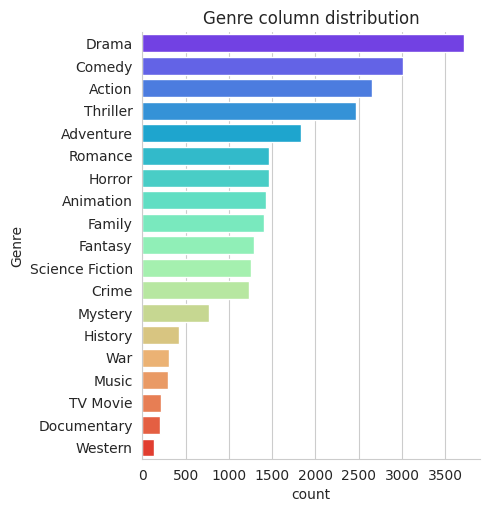

In [ ]:
sns.catplot(y = 'Genre', data = data, kind = 'count', order = data['Genre'].value_counts().index,palette = 'rainbow')
plt.title('Genre column distribution')
plt.show()

Which has highest votes in vote avg column?

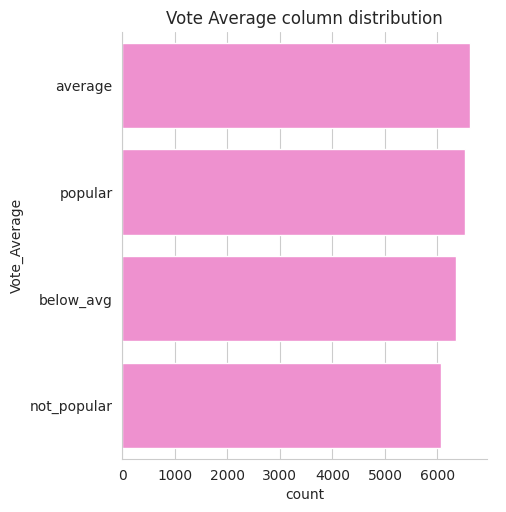

In [ ]:
sns.catplot(y = 'Vote_Average', data = data, kind = 'count', order = data['Vote_Average'].value_counts().index,color = '#FE81D4')
plt.title('Vote Average column distribution')
plt.show()

What movie got the highest popularity? What's the genre?

In [ ]:
data[data['Popularity'] == data['Popularity'].max()][['Title','Popularity','Genre']]

,Title,Popularity,Genre
0,Spider-Man: No Way Home,5083.954,Action
1,Spider-Man: No Way Home,5083.954,Adventure
2,Spider-Man: No Way Home,5083.954,Science Fiction


What movie got the lowest popularity? What's its genre?

In [ ]:
data[data['Popularity'] == data['Popularity'].min()][['Title','Popularity','Genre']]

,Title,Popularity,Genre
25546,The United States vs. Billie Holiday,13.354,Music
25547,The United States vs. Billie Holiday,13.354,Drama
25548,The United States vs. Billie Holiday,13.354,History
25549,Threads,13.354,War
25550,Threads,13.354,Drama
25551,Threads,13.354,Science Fiction


Which year has the most filmmed movies?

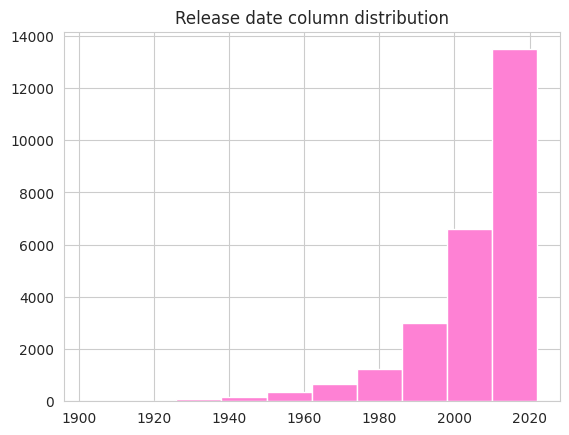

In [ ]:
data['Release_Date'].hist(color = '#FE81D4')
plt.title('Release date column distribution')
plt.show()

In [ ]:
data

,Release_Date,Title,Popularity,Vote_Count,Vote_Average,Genre
0,2021,Spider-Man: No Way Home,5083.954,8940,popular,Action
1,2021,Spider-Man: No Way Home,5083.954,8940,popular,Adventure
2,2021,Spider-Man: No Way Home,5083.954,8940,popular,Science Fiction
3,2022,The Batman,3827.658,1151,popular,Crime
4,2022,The Batman,3827.658,1151,popular,Mystery
...,...,...,...,...,...,...
25547,2021,The United States vs. Billie Holiday,13.354,152,average,Drama
25548,2021,The United States vs. Billie Holiday,13.354,152,average,History
25549,1984,Threads,13.354,186,popular,War
25550,1984,Threads,13.354,186,popular,Drama
